# Five-Number Summary

The five-number summary is a quick way to describe a dataset using just five values:

1. **Minimum** - the smallest value
2. **Q1** - the 25th percentile
3. **Median (Q2)** - the 50th percentile
4. **Q3** - the 75th percentile
5. **Maximum** - the largest value

Together these five numbers give a fast picture of where the data starts, where it's centered, how spread out the middle 50% is, and where it ends.

We'll compute this for the `total_bill` column from the tips dataset.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Calculating the Five Numbers

Let's compute all five values for `total_bill`: minimum, Q1, median, Q3, and maximum.

In [5]:
minimum = df['total_bill'].min()
q1 = df['total_bill'].quantile(0.25)
median = df['total_bill'].median()
q3 = df['total_bill'].quantile(0.75)
maximum = df['total_bill'].max()

print(f"Minimum: {minimum:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Median (Q2): {median:.2f}")
print(f"Q3: {q3:.2f}")
print(f"Maximum: {maximum:.2f}")

Minimum: 3.07
Q1: 13.35
Median (Q2): 17.80
Q3: 24.13
Maximum: 50.81


In [3]:
# We can also do this by pandas built in function

df['total_bill'].describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

## Interquartile Range (IQR)

The interquartile range measures how spread out the middle 50% of the data is. It's simply:

$$IQR = Q3 - Q1$$

IQR matters because it ignores the extreme ends of the data (the bottom 25% and top 25%), so it gives a spread measure that isn't thrown off by outliers, unlike range, which uses the min and max directly.

In [6]:
iqr = q3 - q1
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")

Q1: 13.35
Q3: 24.13
IQR: 10.78


## Using IQR to Spot Outliers

A common rule of thumb is that any value sitting far outside the IQR is considered an outlier. The usual cutoff is 1.5 times the IQR beyond Q1 and Q3:

$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$

$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$

Any value below the lower bound or above the upper bound is flagged as a potential outlier. This is also exactly what the little dots outside the whiskers represent in a box plot.

In [7]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]

print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {outliers.shape[0]}")
outliers[['total_bill']]

Lower bound: -2.82
Upper bound: 40.30
Number of outliers: 9


,total_bill
59,48.27
102,44.30
142,41.19
156,48.17
170,50.81
182,45.35
184,40.55
197,43.11
212,48.33


## A Note on Negative Bounds

Our calculated lower bound came out as **-2.82**, even though `total_bill` obviously can't be negative in real life. This doesn't mean anything is wrong.

The lower bound is just a threshold: any value *below* it would count as an outlier. Since our actual minimum (3.07) is already above -2.82, it simply means there are no unusually small outliers on the low end. The bound doesn't replace or change the real minimum, it's just a line we check values against.

This can happen whenever the data is tightly packed on the low end, the formula allows room below the real minimum without finding anything there.

## Visualizing It All: Box Plot

A box plot puts the five-number summary and the outliers together in one picture. The box spans Q1 to Q3, the line inside is the median, the whiskers reach out to the min/max within the bounds, and any dots beyond the whiskers are the outliers we just calculated.

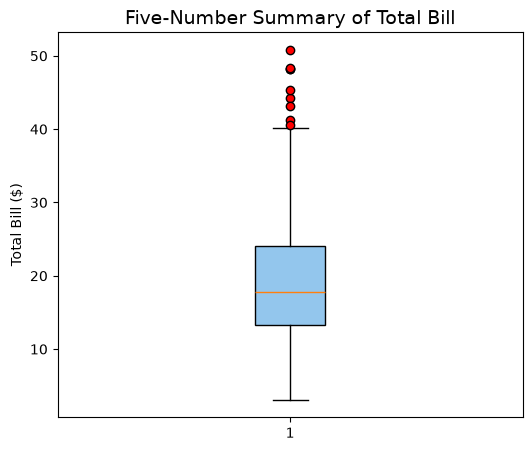

In [8]:
plt.figure(figsize=(6, 5))
plt.boxplot(df['total_bill'], patch_artist=True,
            boxprops=dict(facecolor='#93C6ED'),
            flierprops=dict(markerfacecolor='red', marker='o'))
plt.title('Five-Number Summary of Total Bill', fontsize=14)
plt.ylabel('Total Bill ($)')
plt.show()

## Reading the Box Plot

This matches everything we calculated by hand:

* The **box** spans from Q1 (13.35) to Q3 (24.13), so the middle 50% of all bills fall inside this range.
* The **orange line** inside the box is the median (17.80), slightly left of center, which hints the data isn't perfectly symmetric.
* The **whiskers** stretch down to the real minimum (3.07) on the low end, since nothing falls below our lower bound (-2.82).
* On the high end, the whisker stops at 40.17 (our upper bound), not at the actual maximum. Anything past that point is plotted separately.
* The **red dots** above the upper whisker are the outliers we found earlier, bills that are unusually high compared to the rest of the dataset. These are the big spenders in the data.

So this one chart visually confirms everything from the five-number summary, the IQR, and the outlier bounds, all at once.